## Bibliotekos

In [1]:
library(dplyr)
library(ggplot2)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## Duomenys

In [2]:
data <- read.csv(file.path("..", "..", "python", "datasets_prep", "dm_project_dataset.csv"), sep = ',')
data$time <- as.Date(data$observationTime)
dim(data)

[1] 2772   32

In [3]:
head(data)

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,⋯,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,time
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>
1,2018-07-01,-1.0162473,7.533331e-05,6.183662e-05,0.0001933129,22057.93,1136.782,4.376100e+13,1.489699e+13,3.627587e+15,⋯,11.29583,1010.638,72.79167,9.1,89.37500,10.93333,3.762500,13.9,356,2018-07-01
2,2018-07-02,-0.8006216,7.926575e-05,6.572057e-05,0.0001963793,22067.76,1229.532,3.946727e+13,1.611675e+13,3.795988e+15,⋯,10.86667,1006.663,94.00000,11.9,91.50000,10.42917,2.516667,7.0,327,2018-07-02
3,2018-07-03,-0.6212348,7.699571e-05,6.164219e-05,0.0002032877,19219.67,1314.681,4.465846e+13,1.499280e+13,4.526218e+15,⋯,13.38750,1008.454,90.04167,10.0,89.37500,13.38750,2.537500,8.3,271,2018-07-03
4,2018-07-04,-0.6591799,7.192521e-05,6.535854e-05,0.0001463974,19219.45,1824.428,4.888972e+13,1.430855e+13,4.149200e+15,⋯,13.59167,1009.237,88.29167,13.9,88.33333,13.59167,2.358333,8.7,288,2018-07-04
5,2018-07-05,-1.0102344,7.921198e-05,6.705435e-05,0.0001983014,19218.37,1257.064,4.093649e+13,1.583584e+13,3.959891e+15,⋯,16.29167,1008.079,70.20833,0.0,66.00000,16.29167,1.283333,6.1,293,2018-07-05
6,2018-07-06,-1.1754774,8.286563e-05,6.885977e-05,0.0001936762,19223.54,1455.858,2.298473e+13,1.981660e+13,3.959520e+15,⋯,17.68750,1008.171,68.16667,0.0,51.33333,17.68750,3.108333,10.4,275,2018-07-06


## Išskirčių analizė

### Išskirčių skaičius pagal tarpkvartilinį plotą

In [4]:
count_outliers_IQR <- function(data, var_name) {
  data %>%
    summarise(
      variable = var_name,
      Q1 = quantile(.data[[var_name]], 0.25),
      Q3 = quantile(.data[[var_name]], 0.75),
      H = Q3 - Q1,
      outer_low = Q1 - 3*H,
      outer_high = Q3 + 3*H,
      IQR_extreme_outliers = sum(.data[[var_name]] < outer_low | .data[[var_name]] > outer_high)
      )
}

numeric_cols <- data %>% 
  dplyr::select(where(is.numeric)) %>% 
  names()

results_list <- lapply(numeric_cols, function(col) count_outliers_IQR(data, col))
IQR_outlier_summary <- bind_rows(results_list)
IQR_outlier_summary

variable,Q1,Q3,H,outer_low,outer_high,IQR_extreme_outliers
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
absorbing_aerosol_index,-1.138378e+00,-2.884844e-01,8.498935e-01,-3.688059e+00,2.261196e+00,2
NO2_column_number_density,6.528396e-05,8.654637e-05,2.126241e-05,1.496742e-06,1.503336e-04,61
stratospheric_NO2_column_number_density,2.524213e-05,5.749933e-05,3.225720e-05,-7.152948e-05,1.542709e-04,0
NO2_slant_column_number_density,1.533367e-04,1.924995e-04,3.916279e-05,3.584832e-05,3.099879e-04,3
tropopause_pressure,1.667883e+04,1.926195e+04,2.583122e+03,8.929463e+03,2.701132e+04,10
H2O_column_number_density,4.747029e+02,1.351585e+03,8.768822e+02,-2.155944e+03,3.982232e+03,6
BrO,3.399393e+13,4.762002e+13,1.362609e+13,-6.884342e+12,8.849830e+13,0
BrO_Error,1.435706e+13,1.975258e+13,5.395520e+12,-1.829500e+12,3.593914e+13,1
NO2,1.722114e+15,3.463748e+15,1.741634e+15,-3.502789e+15,8.688651e+15,0


### Tsoutliers paketas

In [9]:
install.packages('tsoutliers')

Installing package into 'C:/Users/eveli/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'tsoutliers' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\eveli\AppData\Local\Temp\RtmpiODhco\downloaded_packages


In [11]:
library(tsoutliers)

outlier_analysis <- tso(ts(data_clean$xgb_precipitation))

print(outlier_analysis)
plot(outlier_analysis)

Warning message in locate.outliers.iloop(resid = resid, pars = pars, cval = cval, :
"stopped when 'maxit.iloop' was reached"
Warning message in locate.outliers.oloop(y = y, fit = fit, types = types, cval = cval, :
"stopped when 'maxit.oloop = 4' was reached"


: 

### Išskirčių skaičius pagal Z reikšmes

In [5]:
count_outliers_z <- function(data, var_name) {
  z_scores <- as.numeric(scale(data[[var_name]]))
  
  data.frame(
    variable = var_name,
    min_z = min(z_scores),
    max_z = max(z_scores),

    Z_rare = sum(abs(z_scores) > 2 & abs(z_scores) <= 3),
    Z_extremely_rare = sum(abs(z_scores) > 3)
  )
}

numeric_cols <- data %>% 
  dplyr::select(where(is.numeric)) %>% 
  names()

results_list <- lapply(numeric_cols, function(col) count_outliers_z(data, col))
Z_outlier_summary <- bind_rows(results_list)
Z_outlier_summary

variable,min_z,max_z,Z_rare,Z_extremely_rare
<chr>,<dbl>,<dbl>,<int>,<int>
absorbing_aerosol_index,-3.7118145,6.189174,83,11
NO2_column_number_density,-2.6226247,14.528527,79,40
stratospheric_NO2_column_number_density,-1.9842917,2.317639,7,0
NO2_slant_column_number_density,-3.7263990,5.396880,119,21
tropopause_pressure,-3.0122566,3.243637,116,13
H2O_column_number_density,-1.4169745,7.316680,99,17
BrO,-3.6303551,3.682699,122,17
BrO_Error,-1.9479264,8.644091,90,2
NO2,-2.3912891,3.993214,31,1


### Bendra išskirčių lentelė

In [6]:
df_1 <- IQR_outlier_summary %>% 
  dplyr::select(variable, IQR_extreme_outliers)

df_2 <- Z_outlier_summary %>% 
  dplyr::select(variable, Z_rare, Z_extremely_rare)

outlier_count_table <- left_join(df_1, df_2, by = "variable")
outlier_count_table

variable,IQR_extreme_outliers,Z_rare,Z_extremely_rare
<chr>,<int>,<int>,<int>
absorbing_aerosol_index,2,83,11
NO2_column_number_density,61,79,40
stratospheric_NO2_column_number_density,0,7,0
NO2_slant_column_number_density,3,119,21
tropopause_pressure,10,116,13
H2O_column_number_density,6,99,17
BrO,0,122,17
BrO_Error,1,90,2
NO2,0,31,1


## Vizualizacija

In [7]:
identify_outliers <- function(data, var_name) {
    stats <- data %>%
        summarise(
            Q1 = quantile(.data[[var_name]], 0.25),
            Q3 = quantile(.data[[var_name]], 0.75),
            H = Q3 - Q1) %>%
        mutate(
            outer_low = Q1 - 3 * H,
            outer_high = Q3 + 3 * H)

    data %>%
        mutate(
            is_outlier = ifelse((.data[[var_name]] < stats$outer_low | .data[[var_name]] > stats$outer_high), 1, 0))
}

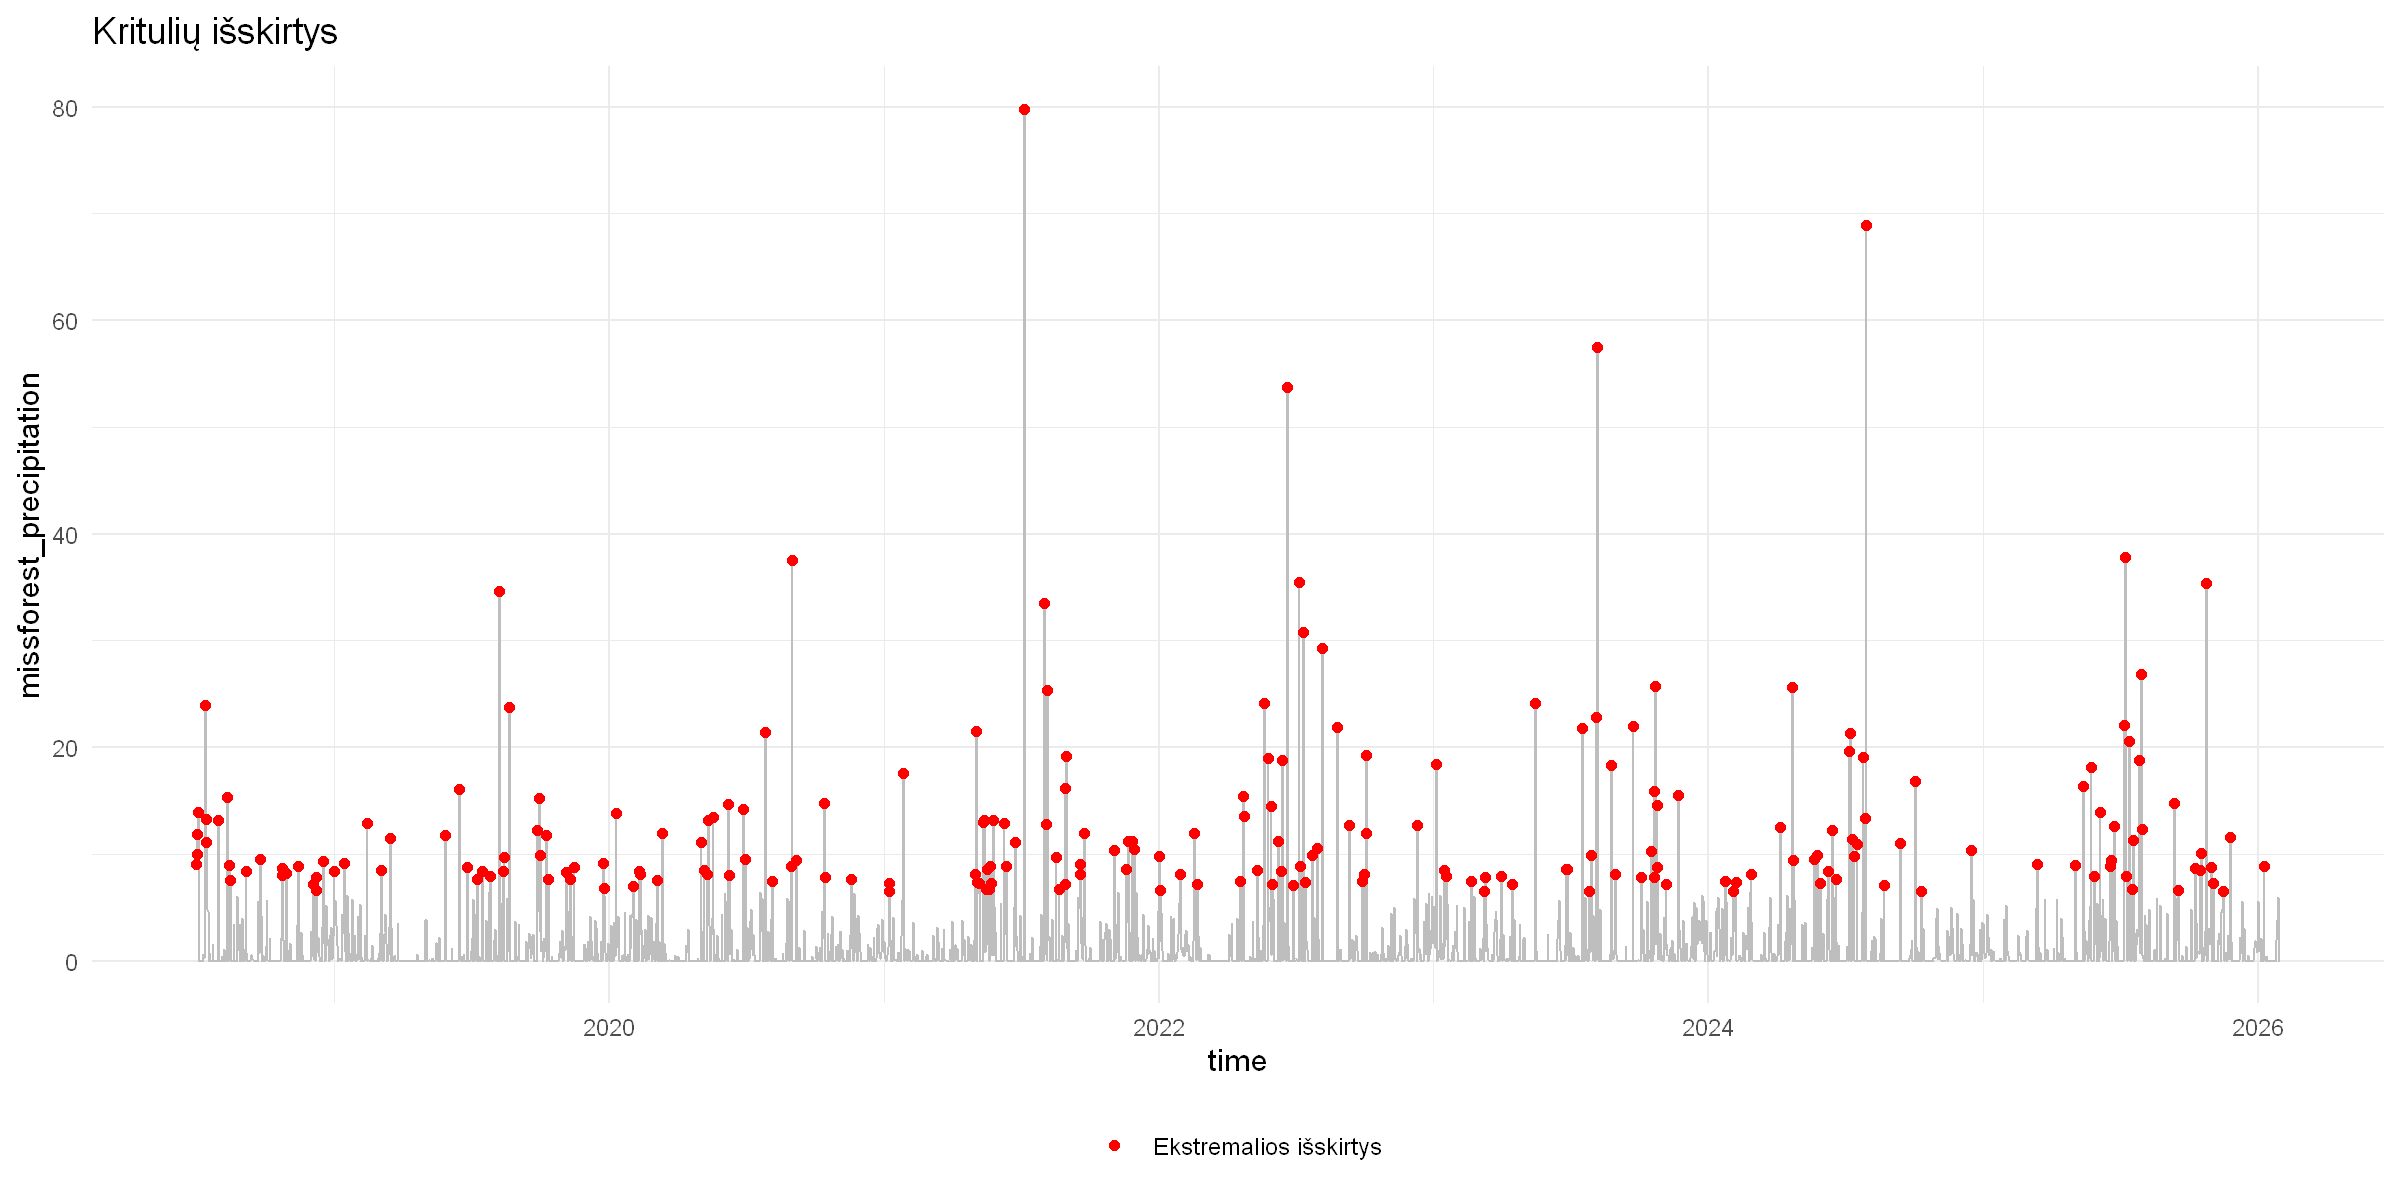

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

data_with_outliers <- identify_outliers(data, 'missforest_precipitation')

ggplot(data_with_outliers, aes(x = time, y = missforest_precipitation, color = as.factor(is_outlier))) +
  geom_line(color = 'grey') +
  geom_point(data = subset(data_with_outliers, is_outlier == 1), 
             aes(color = as.factor(is_outlier))) +
  scale_color_manual(values = c("1" = "red"),
                     labels = c("Ekstremalios išskirtys")) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    legend.title = element_blank()) +
  labs(title = "Kritulių išskirtys", color = "Tipas")

In [9]:
identify_outliers <- function(data, var_name) {
    z_scores <- as.numeric(scale(data[[var_name]]))
    
    stats <- data %>%
        summarise(
            Q1 = quantile(.data[[var_name]], 0.25, na.rm = TRUE),
            Q3 = quantile(.data[[var_name]], 0.75, na.rm = TRUE),
            H = Q3 - Q1) %>%
        mutate(
            outer_low = Q1 - 3 * H,
            outer_high = Q3 + 3 * H
        )

  data %>%
    mutate(
        z_val = z_scores,
        is_outlier = ifelse(abs(z_val) > 3, 2,
                     ifelse((.data[[var_name]] < stats$outer_low | .data[[var_name]] > stats$outer_high), 1, 0))
    )
}

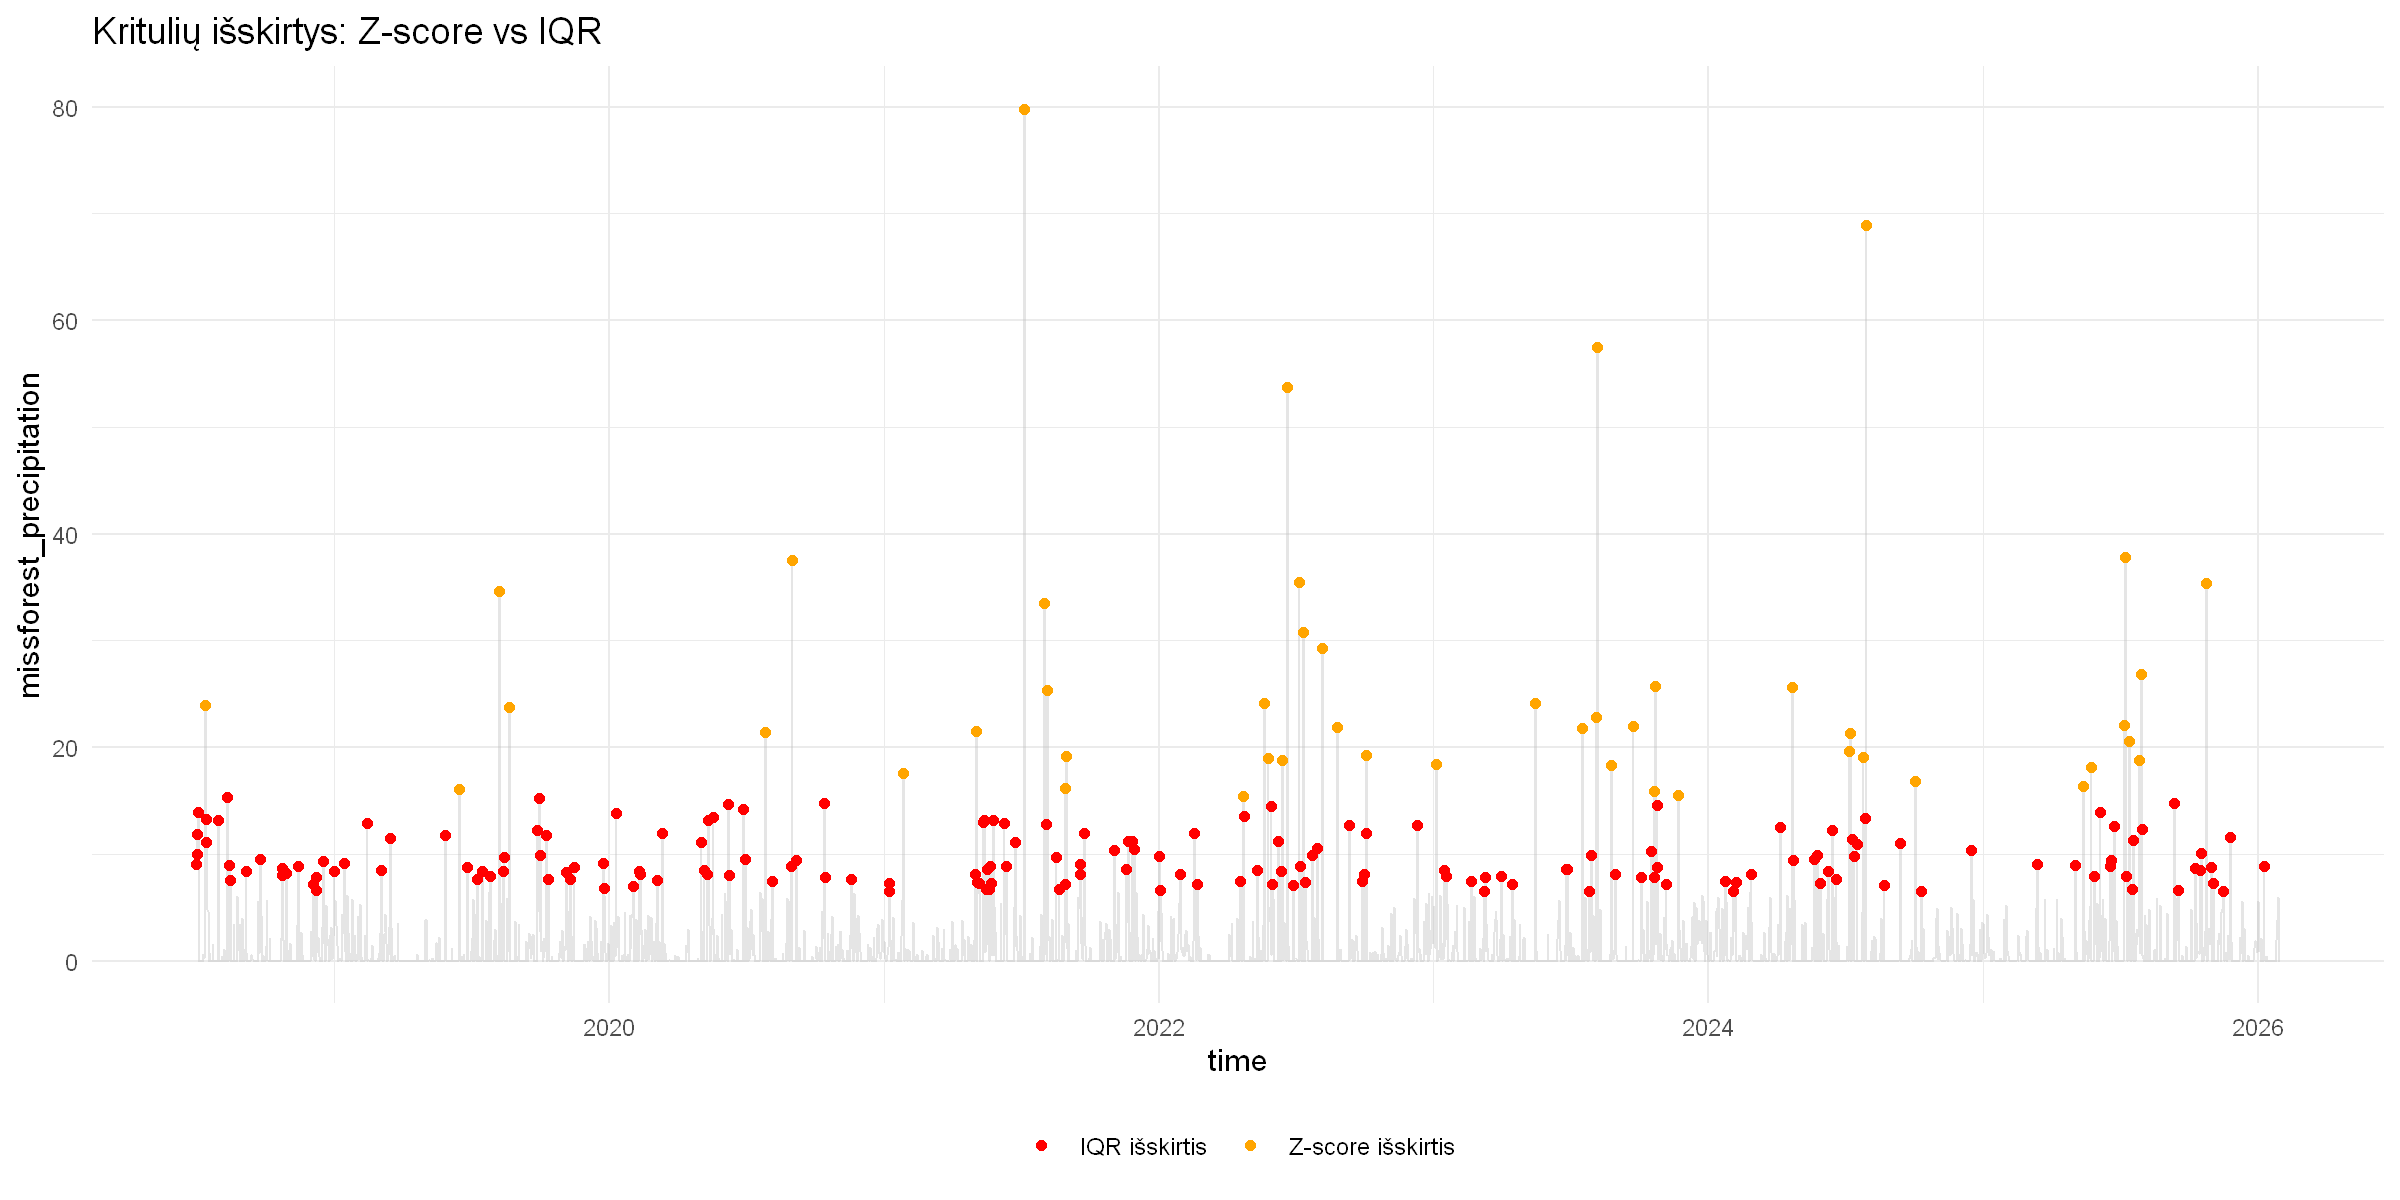

In [11]:
data_with_outliers <- identify_outliers(data, 'missforest_precipitation')

ggplot(data_with_outliers, aes(x = time, y = missforest_precipitation)) +
  geom_line(color = 'grey', alpha = 0.4) +
  
  geom_point(data = subset(data_with_outliers, is_outlier > 0), 
             aes(fill = as.factor(is_outlier), 
                 color = as.factor(is_outlier))) +
  
  scale_fill_manual(values = c("1" = "red", "2" = "red"), 
                    labels = c("IQR išskirtis", "Z-score išskirtis")) +
  
  scale_color_manual(values = c("1" = "red", "2" = "orange"), 
                     labels = c("IQR išskirtis", "Z-score išskirtis")) +
  
  theme_minimal() +
  theme(legend.position = "bottom", legend.title = element_blank()) +
  labs(title = "Kritulių išskirtys: Z-score vs IQR")